# Band Selection

subset selection can be performed using the feature importance parameter of the Random Forest model. The importance of a variable measures how much each spectral band contributes to reducing the classification error in the model. The greater the reduction in the Gini index, the more discriminative the band is between classes. This criterion is combined with the weights of the principal components $A = (a_1, a_2, \dots, a_B)$. These weights indicate the contribution of each spectral band to the construction of the principal components.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

## Import dataset

In [2]:
def load_data():
    data = loadmat('dataset.mat')

    X_train = data['X_train']
    y_train = data['y_train'].ravel()

    X_test = data['X_test']
    y_test = data['y_test'].ravel()

    return X_train, y_train, X_test, y_test

#X variables are the pixels and Y variables are the labels
X_train, y_train, X_test, y_test = load_data()

print("Train X:", X_train.shape)
print("Train y:", y_train.shape)

print("Test X:", X_test.shape)
print("Test y:", y_test.shape)

Train X: (43507, 121)
Train y: (43507,)
Test X: (10809, 121)
Test y: (10809,)


## Firt part: PCA

In [3]:
scaler = StandardScaler()

X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [4]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scale)
X_test_pca = pca.transform(X_test_scale)

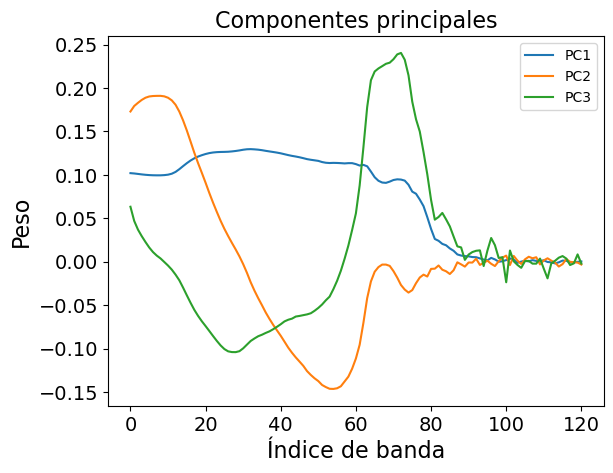

In [5]:
plt.plot(pca.components_[0], label="PC1")
plt.plot(pca.components_[1], label="PC2")
plt.plot(pca.components_[2], label="PC3")

plt.title("Componentes principales", fontsize=16)
plt.xlabel("Índice de banda", fontsize=16)
plt.ylabel("Peso", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend()
plt.show()

In [6]:
loadings = pca.components_
var_exp = pca.explained_variance_ratio_
score_pca = np.sum(np.abs(loadings) * var_exp[:, np.newaxis], axis=0)
indices = np.argsort(score_pca)[::-1]

In [7]:
for i in indices[:15]:
    print(f"Banda {i}: {score_pca[i]:.4f}")

Banda 61: 0.0749
Banda 60: 0.0746
Banda 59: 0.0733
Banda 62: 0.0731
Banda 20: 0.0721
Banda 19: 0.0721
Banda 21: 0.0719
Banda 18: 0.0719
Banda 39: 0.0718
Banda 40: 0.0717
Banda 38: 0.0717
Banda 42: 0.0717
Banda 43: 0.0717
Banda 58: 0.0717
Banda 45: 0.0717


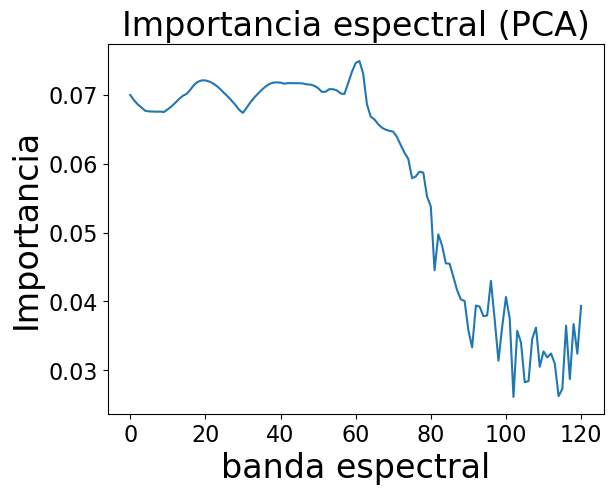

In [8]:
plt.plot(score_pca)
plt.xlabel("Banda",fontsize=24)
plt.ylabel("Importancia PCA",fontsize=24)
plt.title("Importancia espectral (PCA)",fontsize=24)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("banda espectral",fontsize=24)
plt.ylabel("Importancia",fontsize=24)
plt.show()

## Second part: Importances in Random Forest

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.7257840688315292


In [11]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
for i in range(15):
    print(f"Banda {indices[i]} importancia: {importances[indices[i]]:.4f}")

Banda 60 importancia: 0.0344
Banda 10 importancia: 0.0287
Banda 5 importancia: 0.0270
Banda 59 importancia: 0.0224
Banda 48 importancia: 0.0222
Banda 50 importancia: 0.0220
Banda 49 importancia: 0.0216
Banda 61 importancia: 0.0208
Banda 34 importancia: 0.0208
Banda 12 importancia: 0.0201
Banda 9 importancia: 0.0200
Banda 65 importancia: 0.0191
Banda 67 importancia: 0.0185
Banda 7 importancia: 0.0182
Banda 8 importancia: 0.0181


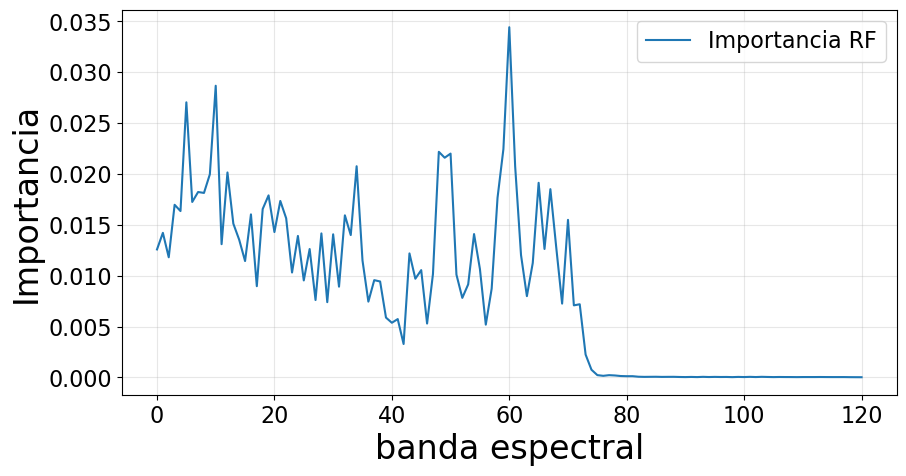

In [12]:
plt.figure(figsize=(10,5))

plt.plot(importances, label="Importancia RF")

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("banda espectral",fontsize=24)
plt.ylabel("Importancia",fontsize=24)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=16)

plt.show()

## Analysis of key band to pigment and dye recognition

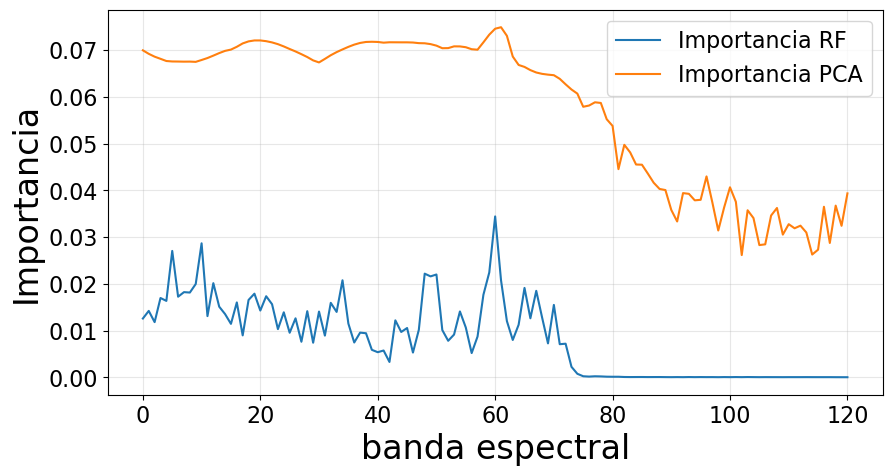

In [13]:
plt.figure(figsize=(10,5))

plt.plot(importances, label="Importancia RF")
plt.plot(score_pca, label="Importancia PCA")

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("banda espectral",fontsize=24)
plt.ylabel("Importancia",fontsize=24)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=16, markerscale=100)

plt.show()

In [14]:
score_pca_norm = score_pca / score_pca.max()
score_rf_norm = importances / importances.max()

score_final = score_pca_norm * score_rf_norm

bandas_ordenadas = np.argsort(score_final)[::-1]

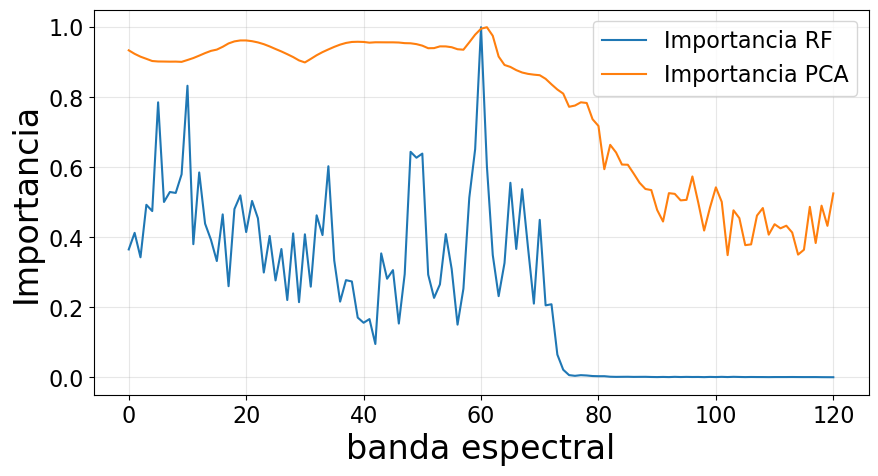

In [15]:
plt.figure(figsize=(10,5))
plt.plot(score_rf_norm, label="Importancia RF")
plt.plot(score_pca_norm, label="Importancia PCA")
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("banda espectral",fontsize=24)
plt.ylabel("Importancia",fontsize=24)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=16, markerscale=100)
plt.show()

In [16]:
for n in [5, 10, 20, 30, 40,60]:
    bandas_n = bandas_ordenadas[:n]
    print(n, bandas_n)

5 [60 10  5 59 48]
10 [60 10  5 59 48 50 61 49 34 12]
20 [60 10  5 59 48 50 61 49 34 12  9 19 65 58 21  7  8 67 18  6]
30 [60 10  5 59 48 50 61 49 34 12  9 19 65 58 21  7  8 67 18  6  3 16 22  4
 32 13 20 70 54 24]
40 [60 10  5 59 48 50 61 49 34 12  9 19 65 58 21  7  8 67 18  6  3 16 22  4
 32 13 20 70 54 24  1 33 28 30 14 11  0 26 62 43]
60 [60 10  5 59 48 50 61 49 34 12  9 19 65 58 21  7  8 67 18  6  3 16 22  4
 32 13 20 70 54 24  1 33 28 30 14 11  0 26 62 43 66 68 35  2 15 45 55 64
 23 47 51 44 37 38 25 53 17 57 31 52]
